In [97]:
import h5py
import numpy as np 
import matplotlib.pyplot as plt
import tools
from scipy.optimize import curve_fit



In [98]:
def read_wilson_loops(filename, B, path = "Configuration", data_name = "loops"):

    all_data = []

    with h5py.File(filename, "r") as f:

        config_keys = list(f[path].keys())

        for cfg in config_keys: 

            T_keys = list(f[f"{path}/{cfg}"].keys())
            cfg_data = []

            for T in T_keys:

                data = f[f"{path}/{cfg}/{T}/{data_name}"][:]
                cfg_data.append(data)

            all_data.append(cfg_data)

    all_data = np.array(all_data)
    means = []
    stds = []

    for r in range(all_data.shape[2]):

        means_r = []
        stds_r = []

        for nt in range(all_data.shape[1]):

            data = all_data[:, nt, r,0]
            #print("Shape of data:", data.shape)
            #print(all_data.shape)
            #print(all_data[0][0].shape)
            #print(data)
            mean, std = tools.bootstrap(B, data)

            means_r.append(mean)
            stds_r.append(std)
        
        means.append(means_r)
        stds.append(stds_r)
    return np.array(means), np.array(stds)

In [99]:
#means, stds  = read_wilson_loops("../h5/Wilson56.h5",200)

##print(means)
#print(stds)

In [100]:
def z3_project(L):

    z3 = np.array([1.0,np.exp(2j*np.pi/3),np.exp(4j*np.pi/3)])
    L_real = np.zeros_like(L.real)

    for i, Lc in enumerate(L):
        distances = np.abs(Lc-z3)
        nearest = z3[np.argmin(distances)]
        #print(np.conj(nearest))
        L_proj = Lc*np.conj(nearest)
        L_real[i]=L_proj.real

    return L_real

In [101]:
def read_polyakov(filename, B, path = "Configuration", data_name = "loops"):

    all_data = []

    with h5py.File(filename, "r") as f:

        config_keys = list(f[path].keys())

        for cfg in config_keys: 

            T_keys = list(f[f"{path}/{cfg}"].keys())
            cfg_data = []

            for T in T_keys:

                data = f[f"{path}/{cfg}/{data_name}"][:]
                cfg_data.append(data)

            all_data.append(cfg_data)

    all_data = np.array(all_data)
    means = []
    stds = []

    for r in range(all_data.shape[2]):

        means_r = []
        stds_r = []

        for nt in range(all_data.shape[1]):

            data = all_data[:, nt, r]
            datacomplex = data[:,0]+1j*data[:,1]

            plt.plot(datacomplex.real, datacomplex.imag,".")
            datareal = z3_project(datacomplex)
            #print("Shape of data:", data.shape)
            #print(all_data.shape)
            #print(all_data[0][0].shape)
            #print(data)
            mean, std = tools.bootstrap(B, datareal)

            means_r.append(mean)
            stds_r.append(std)
        
        means.append(means_r)
        stds.append(stds_r)
    return np.array(means), np.array(stds)

[[0.42043845]]
[[0.0062844]]


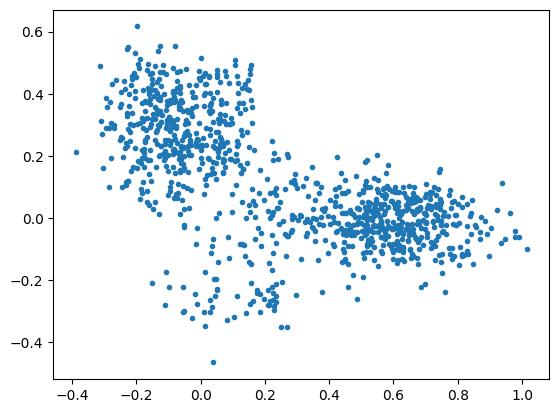

In [ ]:
mean, std = read_polyakov("../h5/Polyakov500.h5", 200)

print(mean)
print(std)

In [ ]:
def calcX(filename, B, path = "Configuration", data_name = "loops"):

    all_data = []

    with h5py.File(filename, "r") as f:

        config_keys = list(f[path].keys())

        for cfg in config_keys: 

            T_keys = list(f[f"{path}/{cfg}"].keys())
            cfg_data = []

            for T in T_keys:

                data = f[f"{path}/{cfg}/{data_name}"][:]
                cfg_data.append(data)

            all_data.append(cfg_data)

    all_data = np.array(all_data)
    means = []
    stds = []
    means2 = []
    stds2 = []
    for r in range(all_data.shape[2]):

        means_r = []
        stds_r = []
        means_r2 = []
        stds_r2 = []        

        for nt in range(all_data.shape[1]):

            data = all_data[:, nt, r]
            datacomplex = data[:,0]+1j*data[:,1]

            plt.plot(datacomplex.real, datacomplex.imag,".")
            datareal = z3_project(datacomplex)
            datareal2 = datareal*datareal
            #print("Shape of data:", data.shape)
            #print(all_data.shape)
            #print(all_data[0][0].shape)
            #print(data)
            mean, std = tools.bootstrap(B, datareal)
            mean2, std2 = tools.bootstrap(B, datareal2)

            means_r.append(mean)
            stds_r.append(std)
            means_r2.append(mean2)
            stds_r2.append(std2)
        
        means.append(means_r)
        stds.append(stds_r)
        means2.append(means_r2)
        stds2.append(stds_r2)
    return np.array(means), np.array(stds), np.array(means2), np.array(stds2)